In [43]:
import pandas as pd

In [44]:
df = pd.read_csv("/content/athlete_events.csv")
region = pd.read_csv("/content/noc_regions.csv")

In [45]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


In [46]:
df.shape

(271116, 15)

In [47]:
df = df[df['Season'] == 'Summer']

In [48]:
region.tail()

,NOC,region,notes
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN
229,ZIM,Zimbabwe,NaN


In [49]:
df = df.merge(region,how="left",on="NOC")

In [50]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
222547,135565,Fernando scar Zylberberg,M,27.0,168.0,76.0,Argentina,ARG,2004 Summer,2004,Summer,Athina,Hockey,Hockey Men's Hockey,NaN,Argentina,NaN
222548,135566,"James Francis ""Jim"" Zylker",M,21.0,175.0,75.0,United States,USA,1972 Summer,1972,Summer,Munich,Football,Football Men's Football,NaN,USA,NaN
222549,135567,Aleksandr Viktorovich Zyuzin,M,24.0,183.0,72.0,Russia,RUS,2000 Summer,2000,Summer,Sydney,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN
222550,135567,Aleksandr Viktorovich Zyuzin,M,28.0,183.0,72.0,Russia,RUS,2004 Summer,2004,Summer,Athina,Rowing,Rowing Men's Lightweight Coxless Fours,NaN,Russia,NaN
222551,135568,Olga Igorevna Zyuzkova,F,33.0,171.0,69.0,Belarus,BLR,2016 Summer,2016,Summer,Rio de Janeiro,Basketball,Basketball Women's Basketball,NaN,Belarus,NaN


In [51]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,9189
Height,51857
Weight,53854
Team,0
NOC,0
Games,0
Year,0


In [52]:
df.duplicated().sum()

np.int64(1385)

In [53]:
df.drop_duplicates(inplace=True)

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
pd.get_dummies(df["Medal"])

,Bronze,Gold,Silver
0,False,False,False
1,False,False,False
2,False,False,False
3,False,True,False
4,False,False,False
...,...,...,...
222547,False,False,False
222548,False,False,False
222549,False,False,False
222550,False,False,False


In [56]:
df.shape

(221167, 17)

In [57]:
df = pd.concat([df,pd.get_dummies(df["Medal"])],axis=1)

In [58]:
df.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False)

,Gold,Silver,Bronze
NOC,,,
USA,2472,1333,1197
URS,832,635,596
GBR,635,729,620
GER,592,538,649
ITA,518,474,454
...,...,...,...
WIF,0,0,5
YEM,0,0,0
YAR,0,0,0


In [59]:
df[(df['NOC'] == 'IND') & (df['Medal'] == 'Gold')]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
4186,2699,Shaukat Ali,M,30.0,NaN,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
4190,2703,Syed Mushtaq Ali,M,22.0,165.0,61.0,India,IND,1964 Summer,1964,Summer,Tokyo,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
4460,2864,Richard James Allen,M,25.0,172.0,NaN,India,IND,1928 Summer,1928,Summer,Amsterdam,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
4461,2864,Richard James Allen,M,30.0,172.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
4462,2864,Richard James Allen,M,34.0,172.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191759,117232,Dung Dung Sylvanus,M,31.0,160.0,62.0,India,IND,1980 Summer,1980,Summer,Moskva,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
193964,118553,Carlyle Carrol Tapsell,M,23.0,182.0,NaN,India,IND,1932 Summer,1932,Summer,Los Angeles,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
193965,118553,Carlyle Carrol Tapsell,M,27.0,182.0,NaN,India,IND,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False
205949,125560,"Max ""Maxie"" Vaz",M,NaN,NaN,NaN,India,IND,1948 Summer,1948,Summer,London,Hockey,Hockey Men's Hockey,Gold,India,NaN,False,True,False


In [60]:
medal_tally = df.drop_duplicates(subset = ['NOC','Games','Year','City','Sport','Event','Medal'])

In [61]:
temp_data = medal_tally.groupby('NOC').sum()[['Gold','Silver','Bronze']].sort_values('Gold',ascending=False).reset_index()
temp_data

,NOC,Gold,Silver,Bronze
0,USA,1035,802,707
1,URS,394,317,294
2,GBR,278,316,298
3,FRA,233,255,282
4,GER,233,261,282
...,...,...,...,...
225,WIF,0,0,2
226,YEM,0,0,0
227,YAR,0,0,0
228,YMD,0,0,0


In [62]:
temp_data[temp_data['NOC'] == 'IND']

,NOC,Gold,Silver,Bronze
50,IND,9,7,12


In [63]:
year = df['Year'].unique().tolist()

In [64]:
year.sort()

In [65]:
country = df['region'].dropna().unique().tolist()

In [66]:
country

['China',
 'Denmark',
 'Netherlands',
 'Finland',
 'Norway',
 'Romania',
 'Estonia',
 'France',
 'Morocco',
 'Spain',
 'Egypt',
 'Iran',
 'Bulgaria',
 'Italy',
 'Chad',
 'Azerbaijan',
 'Sudan',
 'Russia',
 'Argentina',
 'Cuba',
 'Belarus',
 'Greece',
 'Cameroon',
 'Turkey',
 'Chile',
 'Mexico',
 'USA',
 'Nicaragua',
 'Hungary',
 'Nigeria',
 'Algeria',
 'Kuwait',
 'Bahrain',
 'Pakistan',
 'Iraq',
 'Syria',
 'Lebanon',
 'Qatar',
 'Malaysia',
 'Germany',
 'Canada',
 'Ireland',
 'Australia',
 'South Africa',
 'Eritrea',
 'Tanzania',
 'Jordan',
 'Tunisia',
 'Libya',
 'Belgium',
 'Djibouti',
 'Palestine',
 'Comoros',
 'Kazakhstan',
 'Brunei',
 'India',
 'Saudi Arabia',
 'Maldives',
 'Ethiopia',
 'United Arab Emirates',
 'Yemen',
 'Indonesia',
 'Philippines',
 'Uzbekistan',
 'Kyrgyzstan',
 'Tajikistan',
 'Japan',
 'Republic of Congo',
 'Switzerland',
 'Brazil',
 'Monaco',
 'Israel',
 'Uruguay',
 'Sweden',
 'Sri Lanka',
 'Armenia',
 'Ivory Coast',
 'Kenya',
 'Benin',
 'UK',
 'Ghana',
 'Somalia

In [67]:
country.insert(0,'Overall')

In [68]:
def fetch_medal_tally(year,country):
  flag = 0
  if year == 'Overall' and country == 'Overall':
    temp_df = medal_tally
  if year == 'Overall' and country != 'Overall':
    flag = 1
    temp_df = medal_tally[medal_tally['region'] == country]
  if year != 'Overall' and country == 'Overall':
    temp_df = medal_tally[medal_tally['Year'] == int(year)]
  if year != 'Overall' and country != 'Overall':
    temp_df = medal_tally[medal_tally['region'] == country and medal_tally['Year'] == int(year)]

  if flag == 1:
    x = temp_df.groupby('Year').sum()[['Gold','Silver','Bronze']].sort_values('Year').reset_index()
    x['total'] = x['Gold'] + x['Silver'] + x['Bronze']
  else:
    x = temp_df.groupby('Region').sum()[['Gold','Silver','Bronze']].sort_values('Year').reset_index()
    x['total'] = x['Gold'] + x['Silver'] + x['Bronze']
  print(x)


In [69]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False


In [70]:
df['City'].unique().shape[0]

23

In [71]:
df['Sport'].unique().shape[0]

52

In [72]:
df['region'].unique().shape[0]

206

In [73]:
df['Name'].unique().shape[0]

116122

In [74]:
df['Year'].unique().shape[0] - 1

28

In [75]:
nation_over_time = df.drop_duplicates(['Year', 'region'])['Year'].value_counts().reset_index().sort_values('Year',ascending=False)
nation_over_time

,Year,count
0,2016,204
1,2012,203
2,2008,202
3,2004,200
4,2000,199
5,1996,196
6,1992,168
7,1988,156
8,1984,139
14,1980,80


In [76]:
import plotly.express as px

In [78]:
fig1 = px.line(nation_over_time, x = 'Year', y = 'count', title = 'Participating Nations Over The Years')
fig1.show()

In [79]:
event_over_time = df.drop_duplicates(['Year', 'Event'])['Year'].value_counts().reset_index().sort_values('Year',ascending=False)
event_over_time

,Year,count
0,2016,306
2,2012,302
1,2008,302
3,2004,301
4,2000,300
5,1996,271
6,1992,257
7,1988,237
8,1984,221
9,1980,203


In [80]:
fig2 = px.line(event_over_time, x = 'Year', y = 'count', title = 'No. of events Over The Years')
fig2.show()

In [87]:
x = df.drop_duplicates(['Year', 'Sport', 'Event'])

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Year', ylabel='Sport'>

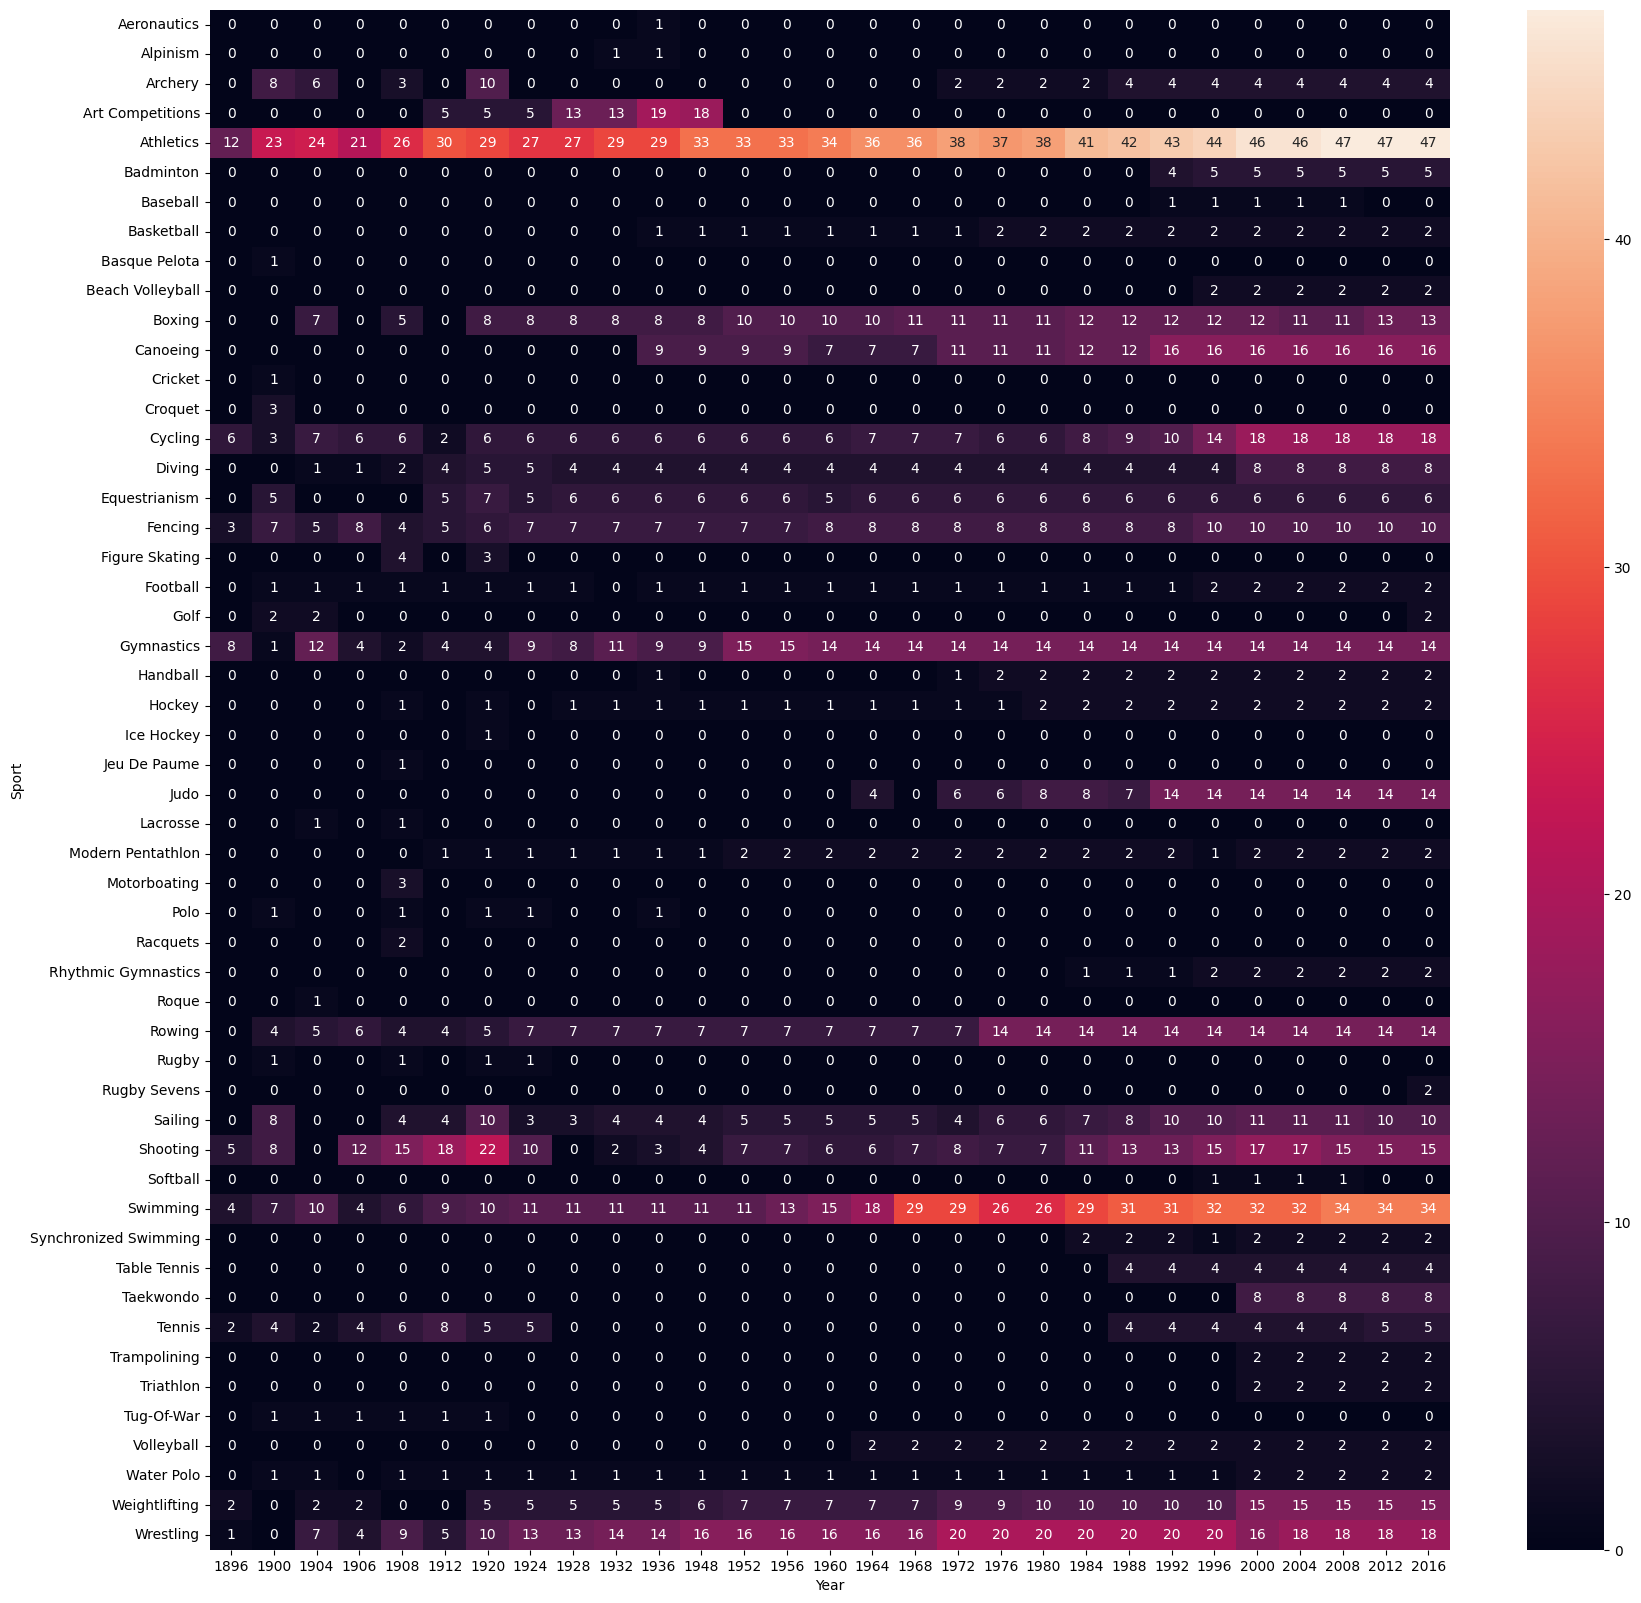

In [88]:
plt.figure(figsize=(20,20))
sns.heatmap(x.pivot_table(index='Sport', columns='Year', values='Event', aggfunc='count').fillna(0).astype('int'), annot=True)

In [89]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False


In [121]:
def most_successful(temp_df,sport):
  temp_df = temp_df.dropna(subset=['Medal'])

  if sport != 'Overall':
    temp_df = temp_df[temp_df['Sport'] == sport]

  return temp_df['Name'].value_counts().reset_index().head(15).merge(df,left_on='Name',right_on='Name',how='left')[['Name','count','Sport','region']].drop_duplicates('Name')

In [122]:
most_successful(df,'Overall')
#

,Name,count,Sport,region
0,"Michael Fred Phelps, II",28,Swimming,USA
30,Larysa Semenivna Latynina (Diriy-),18,Gymnastics,Russia
49,Nikolay Yefimovich Andrianov,15,Gymnastics,Russia
73,Borys Anfiyanovych Shakhlin,13,Gymnastics,Russia
97,Takashi Ono,13,Gymnastics,Japan
130,Edoardo Mangiarotti,13,Fencing,Italy
144,"Dara Grace Torres (-Hoffman, -Minas)",12,Swimming,USA
157,Birgit Fischer-Schmidt,12,Canoeing,Germany
170,"Jennifer Elisabeth ""Jenny"" Thompson (-Cumpelik)",12,Swimming,USA
187,Ryan Steven Lochte,12,Swimming,USA


In [123]:
df.head(2)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,False,False,False
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,False,False,False


In [132]:
def countrywise_medal_tally(df,country):
  temp_df = df.dropna(subset=['Medal'])
  temp_df = df.drop_duplicates(subset=['Team','region','Games','Year','City','Sport','Event','Medal'])
  if country != 'Overall':
    temp_df = temp_df[temp_df['region'] == country]

  return temp_df.groupby('Year').count()['Medal'].reset_index()


In [135]:
countrywise_medal_tally(df,'Overall')

,Year,Medal
0,1896,120
1,1900,300
2,1904,280
3,1906,224
4,1908,322
5,1912,316
6,1920,449
7,1924,391
8,1928,356
9,1932,370


In [134]:
px.line(countrywise_medal_tally(df,'USA'), x = 'Year', y = 'Medal', title = 'Medal Tally Over The Years')

In [145]:
def country_overall_analysis(df,country):
  temp_df = df.dropna(subset=['Medal'])
  temp_df = df.drop_duplicates(subset=['Team','region','Games','Year','City','Sport','Event','Medal'])

  if country != 'Overall':
    temp_df = temp_df[temp_df['region'] == country]

    return temp_df.pivot_table(index='Sport',columns='Year',values='Medal',aggfunc='count').fillna(0)

<Axes: xlabel='Year', ylabel='Sport'>

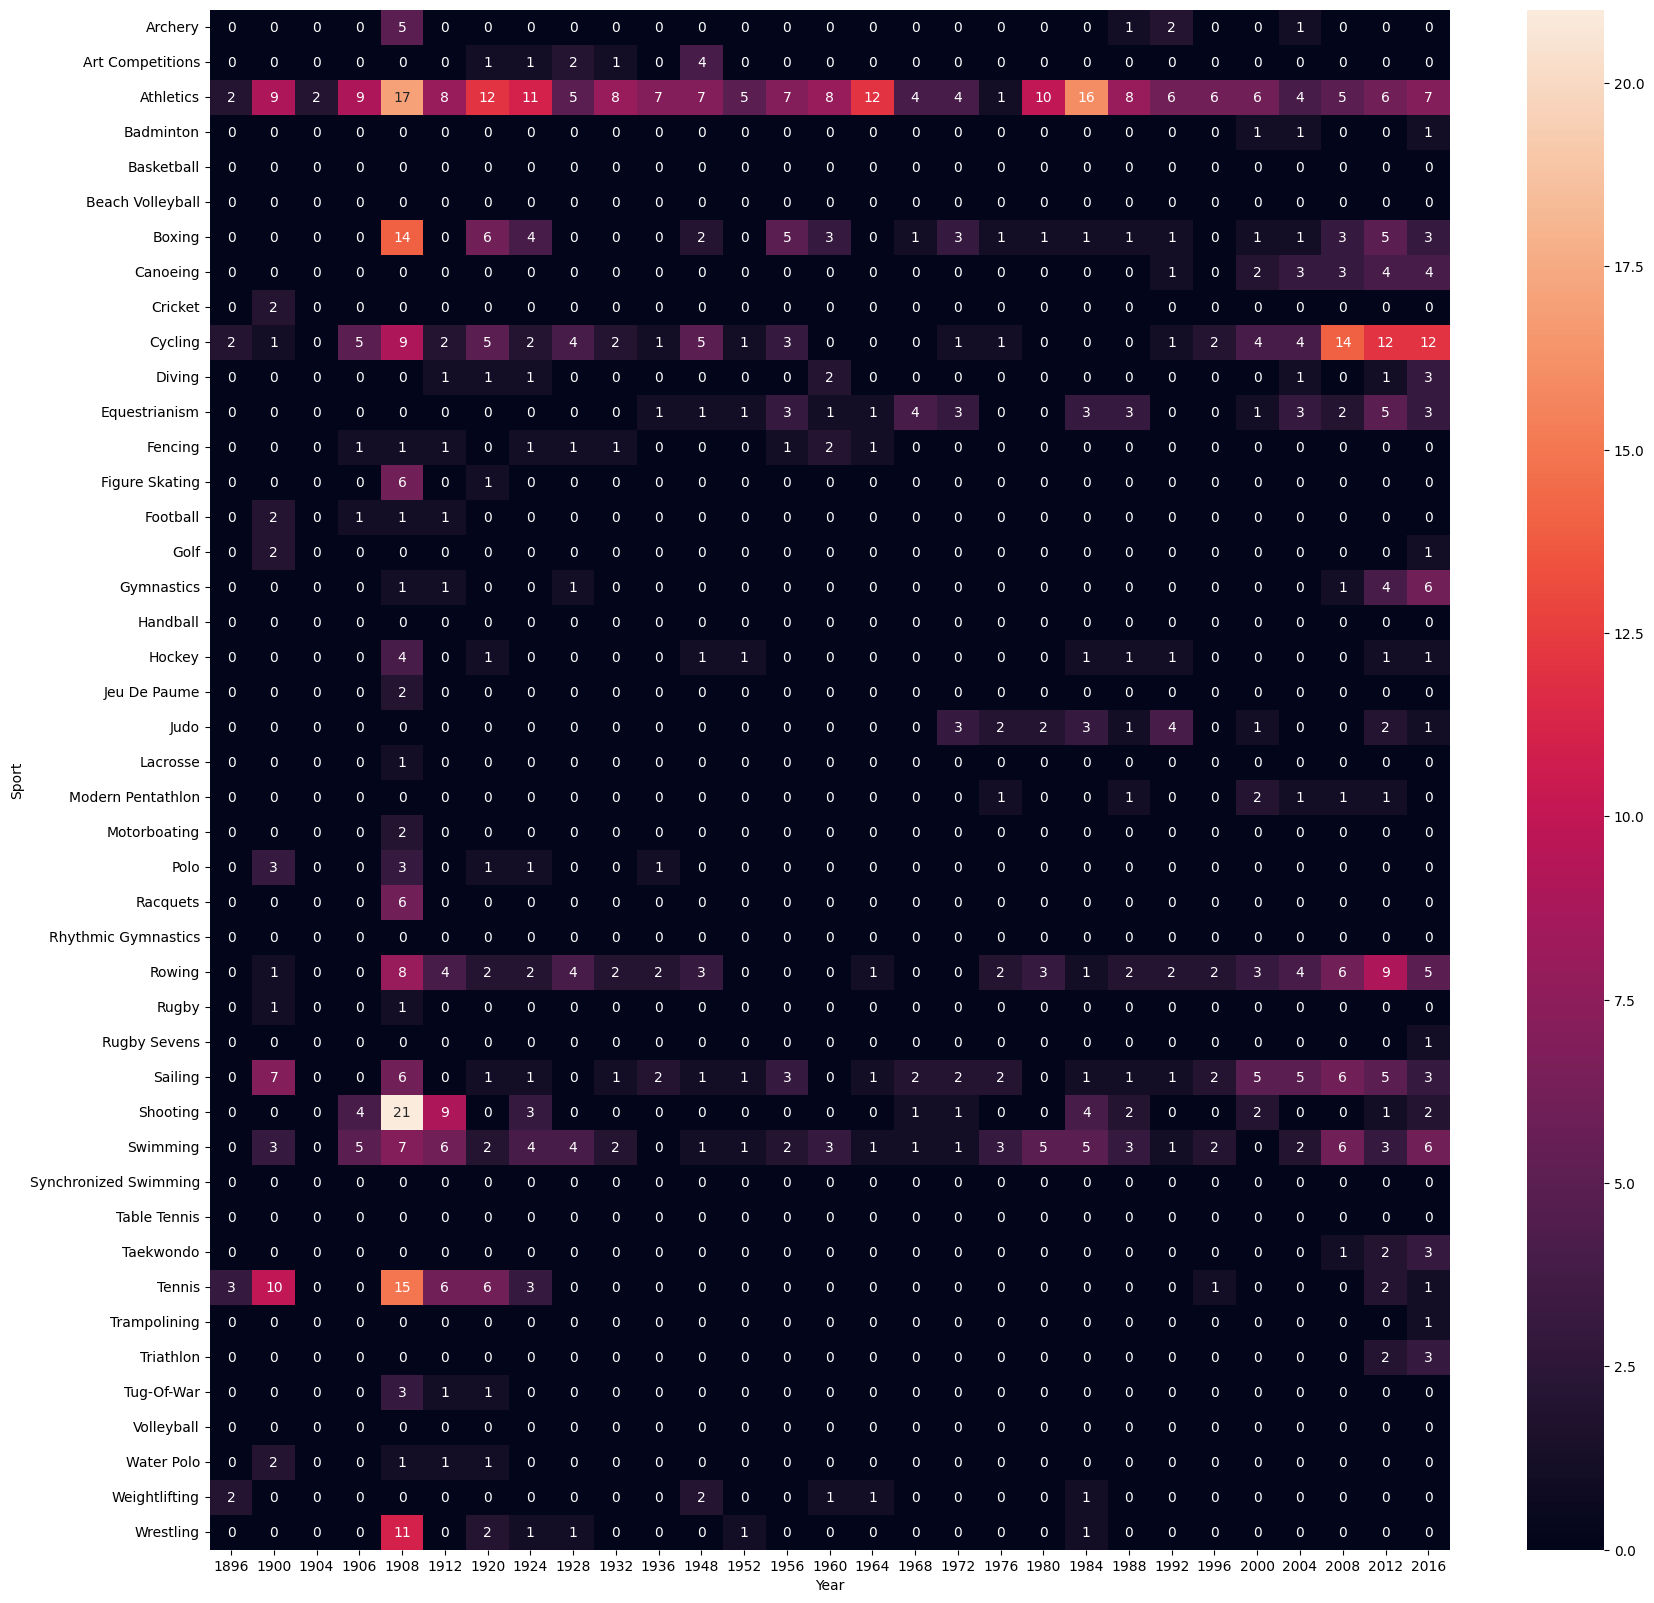

In [151]:
plt.figure(figsize=(20,20))
sns.heatmap(country_overall_analysis(df,'UK'),annot=True)

In [153]:
def most_successful_country(temp_df,region):
  temp_df = temp_df.dropna(subset=['Medal'])

  if region != 'Overall':
    temp_df = temp_df[temp_df['region'] == region]

  return temp_df['Name'].value_counts().reset_index().head(15).merge(df,left_on='Name',right_on='Name',how='left')[['Name','count','Sport']].drop_duplicates('Name')

In [156]:
most_successful_country(df,'Jamaica')

,Name,count,Sport
0,Merlene Joyce Ottey-Page,9,Athletics
19,Veronica Angella Campbell-Brown,8,Athletics
30,Usain St. Leo Bolt,8,Athletics
40,Shelly-Ann Fraser-Pryce,6,Athletics
47,"Herbert Henry ""Herb"" McKenley",4,Athletics
53,"Donald O'Reilly ""Don"" Quarrie",4,Athletics
62,Novlene Hilaire Williams-Mills,4,Athletics
69,Arthur Stanley Wint,4,Athletics
75,Yohan Blake,4,Athletics
81,Deon Marie Hemmings,3,Athletics


In [158]:
import plotly.figure_factory as ff

In [161]:
athelete_df = df.drop_duplicates(subset=['Name','region'])

x1 = athelete_df['Age'].dropna()
x2 = athelete_df[athelete_df['Medal'] == 'Gold']['Age'].dropna()
x3 = athelete_df[athelete_df['Medal'] == 'Silver']['Age'].dropna()
x4 = athelete_df[athelete_df['Medal'] == 'Bronze']['Age'].dropna()
fig = ff.create_distplot([x1,x2,x3,x4],['Overall Age','Gold','Silver','Bronze'],show_hist=False,show_rug=False)
fig.show()

In [162]:
famous_sports = ['Basketball', 'Judo', 'Football', 'Tug-of-war', 'Athletics',
                 'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
                 'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
                 'Water Polo', 'Hockey', 'Rowing', 'Fencing',
                 'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
                 'Tennis', 'Golf', 'Softball', 'Archery',
                 'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
                 'Rhythmic Gymnastics', 'Rugby Sevens',
                 'Beach Volleyball', 'Triathlon', 'Rugby', 'Polo', 'Ice Hockey']

famous_sports

['Basketball',
 'Judo',
 'Football',
 'Tug-of-war',
 'Athletics',
 'Swimming',
 'Badminton',
 'Sailing',
 'Gymnastics',
 'Art Competitions',
 'Handball',
 'Weightlifting',
 'Wrestling',
 'Water Polo',
 'Hockey',
 'Rowing',
 'Fencing',
 'Shooting',
 'Boxing',
 'Taekwondo',
 'Cycling',
 'Diving',
 'Canoeing',
 'Tennis',
 'Golf',
 'Softball',
 'Archery',
 'Volleyball',
 'Synchronized Swimming',
 'Table Tennis',
 'Baseball',
 'Rhythmic Gymnastics',
 'Rugby Sevens',
 'Beach Volleyball',
 'Triathlon',
 'Rugby',
 'Polo',
 'Ice Hockey']

In [166]:
x = []
name = []

for sport in famous_sports:
    temp_df = athelete_df[athelete_df['Sport'] == sport]
    ages = temp_df[temp_df['Medal'] == 'Gold']['Age'].dropna()

    if len(ages) > 0:
        x.append(ages)
        name.append(sport)

fig = ff.create_distplot(x, name, show_hist=False, show_rug=False)
fig.show()

In [172]:
athelete_df['Medal'].fillna('No Medal',inplace=True)

/tmp/ipython-input-3891762689.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





<Axes: xlabel='Weight', ylabel='Height'>

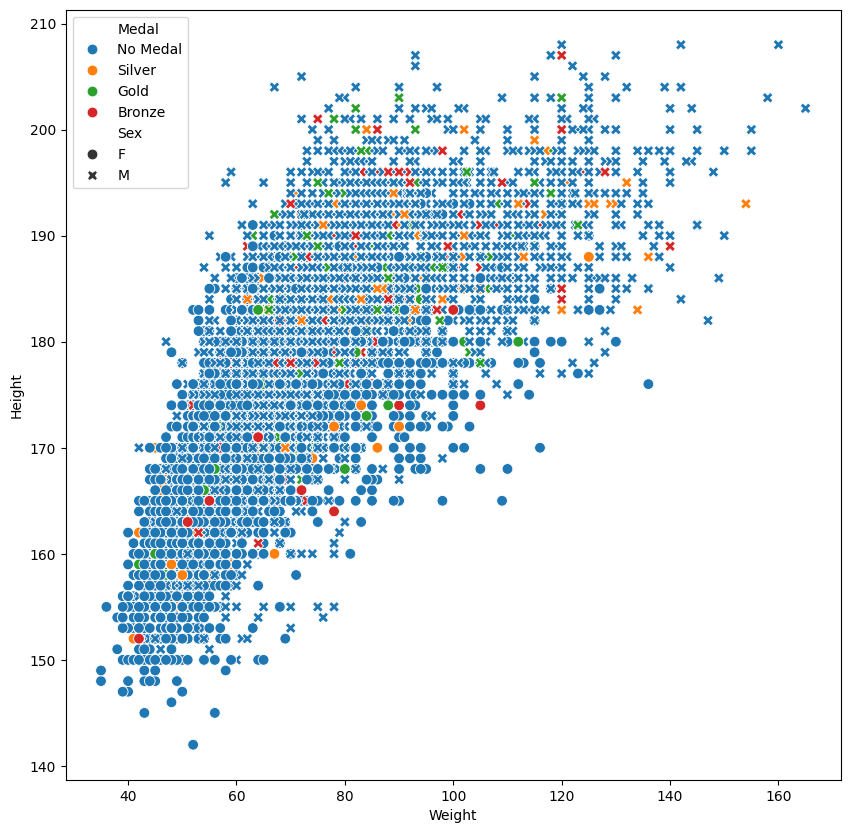

In [175]:
plt.figure(figsize=(10,10))
temp_df = athelete_df[athelete_df['Sport'] == 'Athletics']
sns.scatterplot(x=temp_df['Weight'],y=temp_df['Height'],hue=temp_df['Medal'],style=temp_df['Sex'],s=60)

In [180]:
men = df[df['Sex']=='M'].groupby('Year').count()['Name'].reset_index()
women = df[df['Sex']=='F'].groupby('Year').count()['Name'].reset_index()

,Year,Name
0,1896,380
1,1900,1865
2,1904,1285
3,1906,1722
4,1908,3022
5,1912,3953
6,1920,4158
7,1924,4876
8,1928,4265
9,1932,2200


In [183]:
final = men.merge(women,on='Year',how='left')
final.rename(columns={'Name_x':'Male','Name_y':'Female'},inplace=True)
final.fillna(0,inplace=True)
final = final.astype({'Male':'int','Female':'int'})

In [184]:
fig = px.line(final,x='Year',y=['Male','Female'])
fig.show()